In [ ]:
# PROYECTO:
# SISTEMA INTELIGENTE DE DETECCIÓN DE FRAUDE FINANCIERO
#
# NOTEBOOK:
# modelo_fraude.ipynb
#
# OBJETIVO:
# Entrenar un modelo de Machine Learning capaz de
# identificar transacciones fraudulentas utilizando
# variables operativas y financieras.
#
# AUTOR:
# Dariel Peña - Vision Metrics


In [2]:

# IMPORTACIÓN DE LIBRERÍAS

# Manipulación de datos
import pandas as pd
import numpy as np

# Conexión SQL Server
from sqlalchemy import create_engine

# Machine Learning
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier

# Métricas de evaluación
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score
)

# Visualización
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
# CONEXIÓN A SQL SERVER


# Servidor SQL local
server = 'DARIELPC'

# Base de datos creada previamente
database = 'FraudAnalyticsDB'

# String de conexión utilizando SQLAlchemy
connection_string = (
    f"mssql+pyodbc://@{server}/{database}"
    "?driver=ODBC+Driver+17+for+SQL+Server"
    "&trusted_connection=yes"
)

# Creación del engine de conexión
engine = create_engine(connection_string)

print("Conexión a SQL Server realizada correctamente.")

Conexión a SQL Server realizada correctamente.


In [ ]:

# CARGA DE DATOS DESDE SQL SERVER

# Consulta SQL
query = """
SELECT *
FROM transacciones_financieras
"""

# Lectura de la tabla hacia un DataFrame
df = pd.read_sql(query, engine)

# Visualización inicial
df.head()

,id_transaccion,id_cliente,fecha_transaccion,monto_transaccion,tipo_transaccion,metodo_pago,moneda,pais_origen,ciudad_origen,ip_dispositivo,dispositivo_nuevo,intentos_fallidos,transacciones_24h,promedio_historico_cliente,desviacion_monto,pais_alto_riesgo,transaccion_fuera_horario,multiples_ips,fraude
0,1,49,2026-03-31 03:25:00,331758.10,Transferencia,ACH,DOP,República Dominicana,East Linda,119.119.99.54,True,5,9,158342.63,886240.10,False,True,False,False
1,2,315,2025-09-14 08:55:39,750818.86,Retiro,Transferencia Bancaria,DOP,República Dominicana,Cordovamouth,70.127.214.252,False,5,16,432794.73,680492.07,False,False,True,False
2,3,400,2025-07-11 00:03:28,1393581.51,Pago,Tarjeta,DOP,República Dominicana,North Jennifermouth,135.144.10.93,True,2,10,392279.28,442310.53,False,False,False,False
3,4,167,2025-06-29 07:54:40,2972052.48,Pago,Transferencia Bancaria,DOP,República Dominicana,North Elaineshire,179.42.64.18,True,0,17,122161.76,796999.65,False,False,True,False
4,5,241,2026-02-01 05:13:17,3324620.87,Compra,Transferencia Bancaria,DOP,República Dominicana,Stephenport,12.125.69.63,False,2,1,178966.73,55263.63,False,False,False,False


In [ ]:

# DISTRIBUCIÓN DE LA VARIABLE OBJETIVO

# Cantidad de registros fraude / no fraude
df['fraude'].value_counts()

fraude
False    11854
True      3146
Name: count, dtype: int64

In [ ]:
# Distribución porcentual
df['fraude'].value_counts(normalize=True) * 100

fraude
False    79.026667
True     20.973333
Name: proportion, dtype: float64

In [ ]:
# SELECCIÓN DE VARIABLES PREDICTORAS

# Variables que utilizará el modelo
X = df[[
    'monto_transaccion',
    'dispositivo_nuevo',
    'intentos_fallidos',
    'transacciones_24h',
    'promedio_historico_cliente',
    'desviacion_monto',
    'pais_alto_riesgo',
    'transaccion_fuera_horario',
    'multiples_ips'
]]

# Variable objetivo
y = df['fraude']

In [ ]:
# DIVISIÓN DE DATOS
# 

# Separación entre entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("Datos de entrenamiento:")
print(X_train.shape)

print("\n")

print("Datos de prueba:")
print(X_test.shape)

Datos de entrenamiento:
(12000, 9)


Datos de prueba:
(3000, 9)


In [12]:
# CREACIÓN DEL MODELO

# Modelo Random Forest
modelo = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

# Entrenamiento del modelo
modelo.fit(X_train, y_train)

print("Modelo entrenado correctamente.")

Modelo entrenado correctamente.


In [ ]:
# GENERACIÓN DE PREDICCIONES

# Predicciones sobre el conjunto de prueba
y_pred = modelo.predict(X_test)

# Primeras predicciones
y_pred[:10]

array([ True, False, False, False, False, False, False, False, False,
        True])

In [ ]:
# EVALUACIÓN DEL MODELO - ACCURACY


# Cálculo de precisión general
accuracy = accuracy_score(
    y_test,
    y_pred
)

print(f"Accuracy del modelo: {accuracy:.2f}")

Accuracy del modelo: 1.00


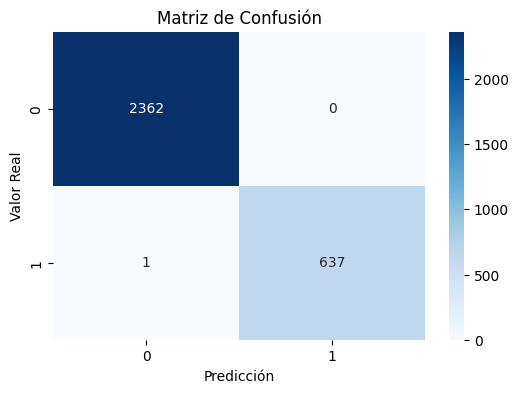

In [ ]:
#MATRIZ DE CONFUSIÓN

# Matriz de confusión
cm = confusion_matrix(
    y_test,
    y_pred
)

# Visualización
plt.figure(figsize=(6,4))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.title('Matriz de Confusión')

plt.xlabel('Predicción')
plt.ylabel('Valor Real')

plt.show()

In [17]:
# REPORTE DE CLASIFICACIÓN


# Métricas completas del modelo
print(
    classification_report(
        y_test,
        y_pred
    )
)

              precision    recall  f1-score   support

       False       1.00      1.00      1.00      2362
        True       1.00      1.00      1.00       638

    accuracy                           1.00      3000
   macro avg       1.00      1.00      1.00      3000
weighted avg       1.00      1.00      1.00      3000



In [19]:
# IMPORTANCIA DE VARIABLES

# DataFrame con importancia de variables
importance = pd.DataFrame({

    'Variable': X.columns,
    'Importancia': modelo.feature_importances_

})

# Ordenar de mayor a menor
importance = importance.sort_values(
    by='Importancia',
    ascending=False
)

importance

,Variable,Importancia
0,monto_transaccion,0.178806
8,multiples_ips,0.163953
1,dispositivo_nuevo,0.159044
2,intentos_fallidos,0.158522
6,pais_alto_riesgo,0.147596
7,transaccion_fuera_horario,0.147172
5,desviacion_monto,0.017943
4,promedio_historico_cliente,0.016983
3,transacciones_24h,0.009981


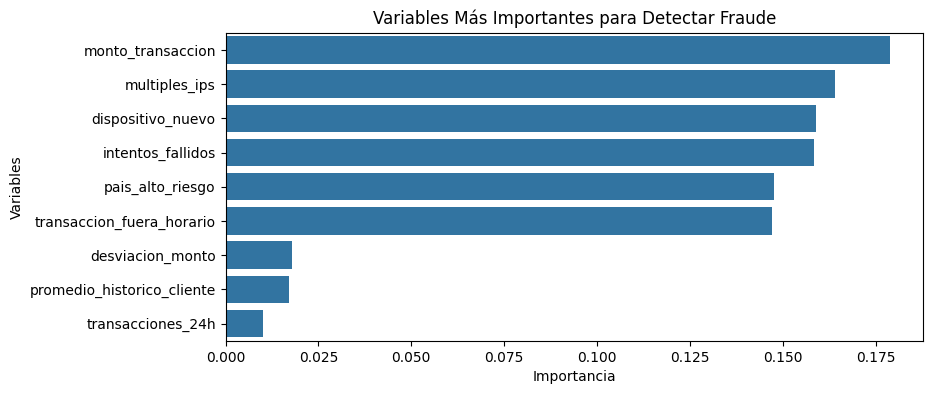

In [23]:
# VISUALIZACIÓN DE IMPORTANCIA

plt.figure(figsize=(9,4))

sns.barplot(
    x='Importancia',
    y='Variable',
    data=importance
)

plt.title('Variables Más Importantes para Detectar Fraude')

plt.xlabel('Importancia')
plt.ylabel('Variables')

plt.show()

In [ ]:
# INSIGHTS DEL MODELO

# Variables como:
# - intentos_fallidos
# - monto_transaccion
# - pais_alto_riesgo
#
#Las transacciones de alto monto, realizadas desde múltiples IPs y 
# dispositivos nuevos, presentan mayor probabilidad de fraude.”
#
# Esto indica que comportamientos anómalos
# y patrones operativos inusuales pueden
# ser utilizados para identificar transacciones
# sospechosas de forma automática.


In [24]:
# Guardar modelo entrenado

import joblib

joblib.dump(
    modelo,
    'modelo_fraude.pkl'
)

print("Modelo guardado correctamente.")

Modelo guardado correctamente.
